# **PHASE 1: CATEGORICAL ENCODERS**

# **Imports + Load Data**

In [1]:
import pandas as pd
import numpy as np
import torch

df = pd.read_csv('/kaggle/input/datasets/waseemalastal/customer-support-ticket-dataset/customer_support_tickets.csv')
df.head()

,Ticket ID,Customer Name,Customer Email,Customer Age,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Description,Ticket Status,Resolution,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,Customer Satisfaction Rating
0,1,Marisa Obrien,carrollallison@example.com,32,Other,GoPro Hero,2021-03-22,Technical issue,Product setup,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Social media,2023-06-01 12:15:36,NaN,NaN
1,2,Jessica Rios,clarkeashley@example.com,42,Female,LG Smart TV,2021-05-22,Technical issue,Peripheral compatibility,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Chat,2023-06-01 16:45:38,NaN,NaN
2,3,Christopher Robbins,gonzalestracy@example.com,48,Other,Dell XPS,2020-07-14,Technical issue,Network problem,I'm facing a problem with my {product_purchase...,Closed,Case maybe show recently my computer follow.,Low,Social media,2023-06-01 11:14:38,2023-06-01 18:05:38,3.0
3,4,Christina Dillon,bradleyolson@example.org,27,Female,Microsoft Office,2020-11-13,Billing inquiry,Account access,I'm having an issue with the {product_purchase...,Closed,Try capital clearly never color toward story.,Low,Social media,2023-06-01 07:29:40,2023-06-01 01:57:40,3.0
4,5,Alexander Carroll,bradleymark@example.com,67,Female,Autodesk AutoCAD,2020-02-04,Billing inquiry,Data loss,I'm having an issue with the {product_purchase...,Closed,West decision evidence bit.,Low,Email,2023-06-01 00:12:42,2023-06-01 19:53:42,1.0


# **Label Encoding**

In [2]:
priority_mapping = {
    "Low": 0,
    "Medium": 1,
    "High": 2
}

df['Priority_Encoded'] = df['Ticket Priority'].map(priority_mapping)
df['Priority_Encoded'] = df['Priority_Encoded'].fillna(-1)

df[['Ticket Priority', 'Priority_Encoded']].head()

,Ticket Priority,Priority_Encoded
0,Critical,-1.0
1,Critical,-1.0
2,Low,0.0
3,Low,0.0
4,Low,0.0


# **One-Hot Encoding Setup**

In [3]:
channels = df['Ticket Channel'].unique()
channel_to_index = {ch: idx for idx, ch in enumerate(channels)}

print(channel_to_index)

{'Social media': 0, 'Chat': 1, 'Email': 2, 'Phone': 3}


# **One-Hot Function**

In [4]:
def one_hot_encode(channel):
    vector = np.zeros(len(channel_to_index))
    
    if channel in channel_to_index:
        index = channel_to_index[channel]
        vector[index] = 1
    else:
        vector = np.zeros(len(channel_to_index))
    
    return vector

# **Apply One-Hot Encoding**

In [5]:
df['Channel_OneHot'] = df['Ticket Channel'].apply(one_hot_encode)

df[['Ticket Channel', 'Channel_OneHot']].head()

,Ticket Channel,Channel_OneHot
0,Social media,"[1.0, 0.0, 0.0, 0.0]"
1,Chat,"[0.0, 1.0, 0.0, 0.0]"
2,Social media,"[1.0, 0.0, 0.0, 0.0]"
3,Social media,"[1.0, 0.0, 0.0, 0.0]"
4,Email,"[0.0, 0.0, 1.0, 0.0]"


# **Validation + Save**

In [6]:
print(len(df))
print(len(df['Priority_Encoded']))
print(len(df['Channel_OneHot']))

df.to_pickle("processed_phase1.pkl")

8469
8469
8469


# **PHASE 2: SPARSE REPRESENTATION (TF-IDF ENGINE)**

# **Load Saved Data**

In [7]:
import pandas as pd
import numpy as np
import re
from collections import Counter

df = pd.read_pickle("processed_phase1.pkl")

# Combine subject + description (better results)
df['text'] = df['Ticket Subject'] + " " + df['Ticket Description']

df['text'].head()

0    Product setup I'm having an issue with the {pr...
1    Peripheral compatibility I'm having an issue w...
2    Network problem I'm facing a problem with my {...
3    Account access I'm having an issue with the {p...
4    Data loss I'm having an issue with the {produc...
Name: text, dtype: object

# **CUSTOM TOKENIZER**

In [8]:
def tokenize(text):
    text = text.lower()
    
    # remove punctuation
    text = re.sub(r'[^a-z0-9\s]', '', text)
    
    tokens = text.split()
    return tokens

# Apply
df['tokens'] = df['text'].apply(tokenize)

df[['text', 'tokens']].head()

,text,tokens
0,Product setup I'm having an issue with the {pr...,"[product, setup, im, having, an, issue, with, ..."
1,Peripheral compatibility I'm having an issue w...,"[peripheral, compatibility, im, having, an, is..."
2,Network problem I'm facing a problem with my {...,"[network, problem, im, facing, a, problem, wit..."
3,Account access I'm having an issue with the {p...,"[account, access, im, having, an, issue, with,..."
4,Data loss I'm having an issue with the {produc...,"[data, loss, im, having, an, issue, with, the,..."


# **N-GRAM GENERATOR**

In [9]:
def generate_ngrams(tokens):
    bigrams = []
    trigrams = []
    
    # bigrams
    for i in range(len(tokens)-1):
        bigrams.append(tokens[i] + "_" + tokens[i+1])
    
    # trigrams
    for i in range(len(tokens)-2):
        trigrams.append(tokens[i] + "_" + tokens[i+1] + "_" + tokens[i+2])
    
    return tokens + bigrams + trigrams

# Apply
df['tokens'] = df['tokens'].apply(generate_ngrams)

df['tokens'].head()

0    [product, setup, im, having, an, issue, with, ...
1    [peripheral, compatibility, im, having, an, is...
2    [network, problem, im, facing, a, problem, wit...
3    [account, access, im, having, an, issue, with,...
4    [data, loss, im, having, an, issue, with, the,...
Name: tokens, dtype: object

# **BUILD VOCABULARY (TOP 5000)**

In [10]:
all_tokens = []

for tokens in df['tokens']:
    all_tokens.extend(tokens)

# Count frequency
token_counts = Counter(all_tokens)

# Select top 5000
vocab_size = 5000
most_common = token_counts.most_common(vocab_size)

# Create mapping
vocab = {word: idx for idx, (word, _) in enumerate(most_common)}

print("Vocab size:", len(vocab))

Vocab size: 5000


# **BAG OF WORDS (TF MATRIX)**

In [11]:
def vectorize(tokens):
    vector = np.zeros(len(vocab))
    
    for word in tokens:
        if word in vocab:
            vector[vocab[word]] += 1
    
    return vector

# Apply
df['bow'] = df['tokens'].apply(vectorize)

df['bow'].head()

0    [3.0, 1.0, 2.0, 0.0, 1.0, 0.0, 2.0, 1.0, 1.0, ...
1    [3.0, 2.0, 3.0, 1.0, 3.0, 0.0, 2.0, 2.0, 2.0, ...
2    [2.0, 3.0, 0.0, 0.0, 2.0, 2.0, 0.0, 2.0, 1.0, ...
3    [3.0, 1.0, 2.0, 1.0, 1.0, 0.0, 2.0, 1.0, 1.0, ...
4    [5.0, 2.0, 1.0, 2.0, 1.0, 1.0, 2.0, 1.0, 1.0, ...
Name: bow, dtype: object

# **COMPUTE IDF**

In [12]:
N = len(df)

df_count = np.zeros(len(vocab))

for tokens in df['tokens']:
    unique_words = set(tokens)
    
    for word in unique_words:
        if word in vocab:
            df_count[vocab[word]] += 1

idf = np.log((N + 1) / (df_count + 1)) + 1  # smoothing

# **COMPUTE TF-IDF**

In [13]:
def compute_tfidf(bow_vector):
    tf = bow_vector / (np.sum(bow_vector) + 1e-8)
    tfidf = tf * idf
    return tfidf

df['tfidf'] = df['bow'].apply(compute_tfidf)

df['tfidf'].head()

0    [0.03168093882760551, 0.010416666665581598, 0....
1    [0.024330961020189033, 0.01599999999872, 0.026...
2    [0.016896500708408282, 0.024999999997916668, 0...
3    [0.029817354190870247, 0.009803921567666282, 0...
4    [0.0418921505167436, 0.016528925618468686, 0.0...
Name: tfidf, dtype: object

# **CONVERT TO TORCH SPARSE**

In [14]:
import torch

def to_sparse(vector):
    indices = np.nonzero(vector)[0]
    values = vector[indices]
    
    i = torch.LongTensor([indices])
    v = torch.FloatTensor(values)
    
    return torch.sparse_coo_tensor(i, v, size=(len(vocab),))

df['tfidf_sparse'] = df['tfidf'].apply(to_sparse)

/tmp/ipykernel_24/258577936.py:7: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:253.)
  i = torch.LongTensor([indices])


# **SAVE PHASE 2**

In [15]:
df.to_pickle("processed_phase2.pkl")

# **PHASE 3: DENSE SEMANTIC LAYER (GloVe)**

# **LOAD DATA**

In [16]:
import pandas as pd
import numpy as np
import torch

df = pd.read_pickle("processed_phase2.pkl")

# **LOAD GLOVE FILE**

In [17]:
glove_path = "/kaggle/input/datasets/tranlemylinh/glove6b300d/glove.6B.300d.txt"

glove_dict = {}

with open(glove_path, 'r', encoding='utf-8') as f:
    for line in f:
        values = line.split()
        word = values[0]
        vector = np.array(values[1:], dtype='float32')
        glove_dict[word] = vector

print("Loaded GloVe words:", len(glove_dict))

Loaded GloVe words: 400000


# **CREATE EMBEDDING MATRIX**

In [18]:
embedding_dim = 300

# vocab from Phase 2
vocab_list = list(vocab.keys())

embedding_matrix = np.zeros((len(vocab_list), embedding_dim))

for word, idx in vocab.items():
    if word in glove_dict:
        embedding_matrix[idx] = glove_dict[word]
    else:
        # OOV handling
        embedding_matrix[idx] = np.random.normal(size=(embedding_dim,))

# **CREATE PYTORCH EMBEDDING LAYER**

In [19]:
embedding_layer = torch.nn.Embedding.from_pretrained(
    torch.tensor(embedding_matrix, dtype=torch.float32),
    freeze=True
)

# **SENTENCE EMBEDDING**

In [20]:
def get_sentence_embedding(tokens, tfidf_vector):
    vectors = []
    weights = []
    
    for word in tokens:
        if word in vocab:
            idx = vocab[word]
            word_vec = embedding_layer(torch.tensor(idx))
            weight = tfidf_vector[idx]
            
            vectors.append(word_vec.detach().numpy())
            weights.append(weight)
    
    if len(vectors) == 0:
        return np.zeros(embedding_dim)
    
    vectors = np.array(vectors)
    weights = np.array(weights)
    
    # TF-IDF weighted average
    weighted_sum = np.sum(vectors * weights[:, None], axis=0)
    return weighted_sum / (np.sum(weights) + 1e-8)

# **APPLY TO ALL DATA**

In [21]:
df['glove_embedding'] = df.apply(
    lambda row: get_sentence_embedding(row['tokens'], row['tfidf']),
    axis=1
)

# **CONVERT TO TORCH TENSOR**

In [22]:
glove_matrix = torch.tensor(
    np.stack(df['glove_embedding'].values),
    dtype=torch.float32
)

# **COSINE SIMILARITY FUNCTION**

In [23]:
def cosine_similarity(query_vec, matrix):
    query_vec = query_vec / (torch.norm(query_vec) + 1e-8)
    matrix = matrix / (torch.norm(matrix, dim=1, keepdim=True) + 1e-8)
    
    return torch.matmul(matrix, query_vec)

# **SAVE PHASE 3**

In [24]:
df.to_pickle("processed_phase3.pkl")
torch.save(glove_matrix, "glove_matrix.pt")

# **PHASE 4**

# **LOAD EVERYTHING**

In [25]:
import pandas as pd
import torch
import numpy as np

df = pd.read_pickle("processed_phase3.pkl")
glove_matrix = torch.load("glove_matrix.pt")

# **REUSE TOKENIZER**

In [26]:
def tokenize(text):
    import re
    text = text.lower()
    text = re.sub(r'[^a-z0-9\s]', '', text)
    return text.split()

# **QUERY → TF-IDF VECTOR**

In [27]:
def query_tfidf(tokens):
    vector = np.zeros(len(vocab))
    
    for word in tokens:
        if word in vocab:
            vector[vocab[word]] += 1
    
    # TF
    tf = vector / (np.sum(vector) + 1e-8)
    
    # TF-IDF
    return tf * idf

# **QUERY → GLOVE VECTOR**

In [28]:
def query_glove(tokens, tfidf_vector):
    return get_sentence_embedding(tokens, tfidf_vector)

# **COSINE SIMILARITY**

In [29]:
def cosine_similarity(query_vec, matrix):
    query_vec = query_vec / (torch.norm(query_vec) + 1e-8)
    matrix = matrix / (torch.norm(matrix, dim=1, keepdim=True) + 1e-8)
    
    return torch.matmul(matrix, query_vec)

# **HYBRID SEARCH FUNCTION**

In [30]:
def hybrid_search(query, alpha=0.5):
    
    # Step 1: Tokenize
    tokens = tokenize(query)
    
    # Step 2: TF-IDF
    tfidf_vec = query_tfidf(tokens)
    
    # Step 3: GloVe
    glove_vec = query_glove(tokens, tfidf_vec)
    
    # Convert to torch
    tfidf_tensor = torch.tensor(tfidf_vec, dtype=torch.float32)
    glove_tensor = torch.tensor(glove_vec, dtype=torch.float32)
    
    # Step 4: Compute similarities
    
    # TF-IDF similarity
    tfidf_matrix = torch.tensor(np.stack(df['tfidf'].values), dtype=torch.float32)
    sim_tfidf = cosine_similarity(tfidf_tensor, tfidf_matrix)
    
    # GloVe similarity
    sim_glove = cosine_similarity(glove_tensor, glove_matrix)
    
    # Step 5: Combine
    final_score = alpha * sim_tfidf + (1 - alpha) * sim_glove
    
    # Step 6: Top 5 results
    top_indices = torch.topk(final_score, 5).indices
    
    return df.iloc[top_indices.numpy()][
        ['Ticket Subject', 'Ticket Type', 'Ticket Priority']
    ]

# **Testing**

In [31]:
result = hybrid_search("payment not working", alpha=0.5)
result

,Ticket Subject,Ticket Type,Ticket Priority
5359,Data loss,Product inquiry,Low
3480,Payment issue,Technical issue,High
8354,Product setup,Technical issue,Critical
4847,Payment issue,Billing inquiry,High
2040,Payment issue,Cancellation request,Medium


# **FINAL PHASE**

# **PART 1: PRECISION@5**

# **PRECISION FUNCTION**

In [32]:
def precision_at_k(results, true_type, k=5):
    top_k = results.head(k)
    correct = sum(top_k['Ticket Type'] == true_type)
    return correct / k

# **EVALUATE ON DATASET**

In [33]:
scores = []

for i in range(100):  # test on 100 samples
    query = df.iloc[i]['Ticket Description']
    true_type = df.iloc[i]['Ticket Type']
    
    results = hybrid_search(query, alpha=0.5)
    
    score = precision_at_k(results, true_type)
    scores.append(score)

print("Average Precision@5:", np.mean(scores))

Average Precision@5: 0.368


# **PART 2: TF-IDF vs GLOVE COMPARISON**

# **SEPARATE SEARCH FUNCTIONS**

In [34]:
def tfidf_search(query):
    return hybrid_search(query, alpha=1.0)

def glove_search(query):
    return hybrid_search(query, alpha=0.0)

# **DISPLAY COMPARISON**

In [35]:
query = "money refund issue"

print("TF-IDF Results:")
display(tfidf_search(query))

print("\nGloVe Results:")
display(glove_search(query))

TF-IDF Results:


,Ticket Subject,Ticket Type,Ticket Priority
5550,Delivery problem,Cancellation request,Low
4129,Cancellation request,Billing inquiry,Critical
4126,Installation support,Billing inquiry,Medium
5636,Network problem,Product inquiry,Low
5624,Delivery problem,Billing inquiry,High



GloVe Results:


,Ticket Subject,Ticket Type,Ticket Priority
3480,Payment issue,Technical issue,High
6693,Software bug,Product inquiry,Low
4847,Payment issue,Billing inquiry,High
5596,Hardware issue,Refund request,Low
1397,Product compatibility,Billing inquiry,Low


# **PART 3: PERFORMANCE GRAPH**

# **TIMING TEST**

In [36]:
import time

batch_sizes = [10, 20, 50, 100]
times = []

for size in batch_sizes:
    queries = df['Ticket Description'][:size]
    
    start = time.time()
    
    for q in queries:
        hybrid_search(q)
    
    end = time.time()
    
    times.append(end - start)

# **PLOT GRAPH**

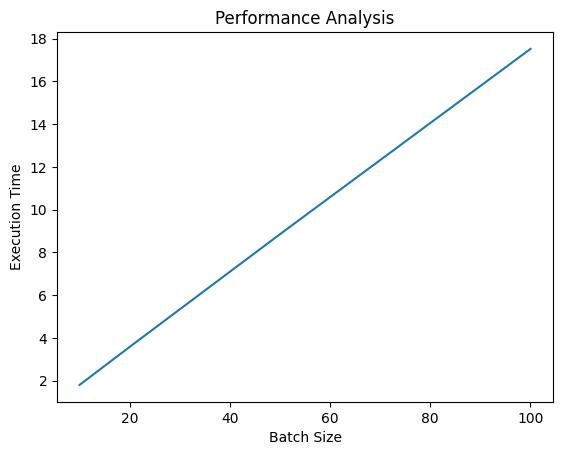

In [37]:
import matplotlib.pyplot as plt

plt.plot(batch_sizes, times)
plt.xlabel("Batch Size")
plt.ylabel("Execution Time")
plt.title("Performance Analysis")
plt.show()

# **PART 4: GRADIO**

# **APP**

In [38]:
import gradio as gr

def search_app(query, alpha):
    results = hybrid_search(query, alpha)
    return results.to_string()

interface = gr.Interface(
    fn=search_app,
    inputs=[
        gr.Textbox(label="Enter Query"),
        gr.Slider(0, 1, value=0.5, label="Alpha")
    ],
    outputs=gr.Textbox(lines=20),
    title="Hybrid Ticket Search System"
)

interface.launch()

* Running on local URL:  http://127.0.0.1:7860
It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

* Running on public URL: https://22f5f19eada2d93733.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
